In [1]:
# Thanks for your patience, kindly see below for the backtested data!
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# The Classics
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt, models as md, backtest as bt
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok = True)
print("Imports OK")

Imports OK


In [3]:
# Download data
stocks_returns, macro_returns, prices = dt.load_data()
print("Computing simple residuals ...")
factor_returns = macro_returns[['SPY', 'IYT']]
residuals = md.compute_simple_residuals(stocks_returns, factor_returns, window = 90)
zscores = md.compute_rolling_zscore(residuals, window = 45)
print("Ready. Residuals shape:", residuals.shape)

Stocks: 20 tickers
Macro columns: ['SPY', 'IYT', 'Brent', 'VIX']
Dates: 2336 trading days
Range: 2017-04-07 -> 2026-07-30
Computing simple residuals ...
Ready. Residuals shape: (2336, 20)


In [4]:
# Finding the signal in the jungle
signals = bt.generate_signals(zscores,
                              entry = bt.entry_threshold,
                              exit_ = bt.exit_threshold,
                              top_n = bt.top_n,
                              min_hold = bt.min_hold_days,
                              momentum = False,
                             )
active = (signals != 0).any(axis = 1)
print(f"Active days: {active.sum()} / {len(signals)} ({active.mean():.1%})")
print(f"\nSignal value counts:")
print(signals.stack().value_counts())

Active days: 472 / 2336 (20.2%)

Signal value counts:
 0.0    46026
 1.0      366
-1.0      328
Name: count, dtype: int64


In [5]:
# Holding period allows for an abnormality in spite of the minimum holding period
holding_periods = []
for col in signals.columns:
    s = signals[col]
    in_pos = False
    count = 0
    for val in s:
        if val != 0:
            count += 1
            in_pos = True
        elif in_pos:
            holding_periods.append(count)
            count = 0
            in_pos = False
    if in_pos and count > 0:
        holding_periods.append(count)

if len(holding_periods) == 0:
    print("No completed positions found.")
    print("Either no signals fired or all positions still open.")
else:
    holding_s = pd.Series(holding_periods)
    print(f"Holding period distribution:")
    print(f"Min: {holding_s.min():.0f} days")
    print(f"Median: {holding_s.median():.0f} days")
    print(f"Mean: {holding_s.mean():.1f} days")
    print(f"Max: {holding_s.max():.0f} days")
    print(f"Positions shorter than 5 days: {(holding_s < 5).sum()}")

Holding period distribution:
Min: 1 days
Median: 6 days
Mean: 6.3 days
Max: 16 days
Positions shorter than 5 days: 1


In [6]:
# As you can see, we generally remain minimally invested to make room for higher opportunity trades
active_days = signals[signals.abs().sum(axis = 1) > 0]
positions_per_day = signals.abs().sum(axis = 1)
print(f"Position count distribution:")
print(positions_per_day[positions_per_day > 0].value_counts().sort_index())

Position count distribution:
1.0    322
2.0     97
3.0     42
4.0      5
5.0      4
6.0      2
Name: count, dtype: int64


In [7]:
# The macro regime filters were added from a previous idea testing to pave the way for regime-adjustments
positions_raw = bt.construct_portfolio(signals, zscores = zscores, residuals = residuals)
positions = bt.apply_macro_regime_filter(positions_raw, macro_returns, vix_window = 90, brent_window = 90)
print(f"Gross exposure: {positions.abs().sum(axis = 1).mean():.3f}")
print(f"Net exposure mean: {positions.sum(axis = 1).abs().mean():.6f}")

Gross exposure: 0.038
Net exposure mean: 0.026516


In [8]:
# We save a lot in transaction costs by minimizing trading frequency
net_returns, trades = bt.compute_portfolio_returns(positions, stocks_returns)
print(f"Ann. turnover: {trades['turnover'].mean()*252:.2f}")
print(f"Ann. cost drag: {trades['transaction_cost'].mean()*252:.2%}")
print(f"Active days: {(net_returns != 0).sum()}")

Ann. turnover: 2.75
Ann. cost drag: 0.27%
Active days: 500


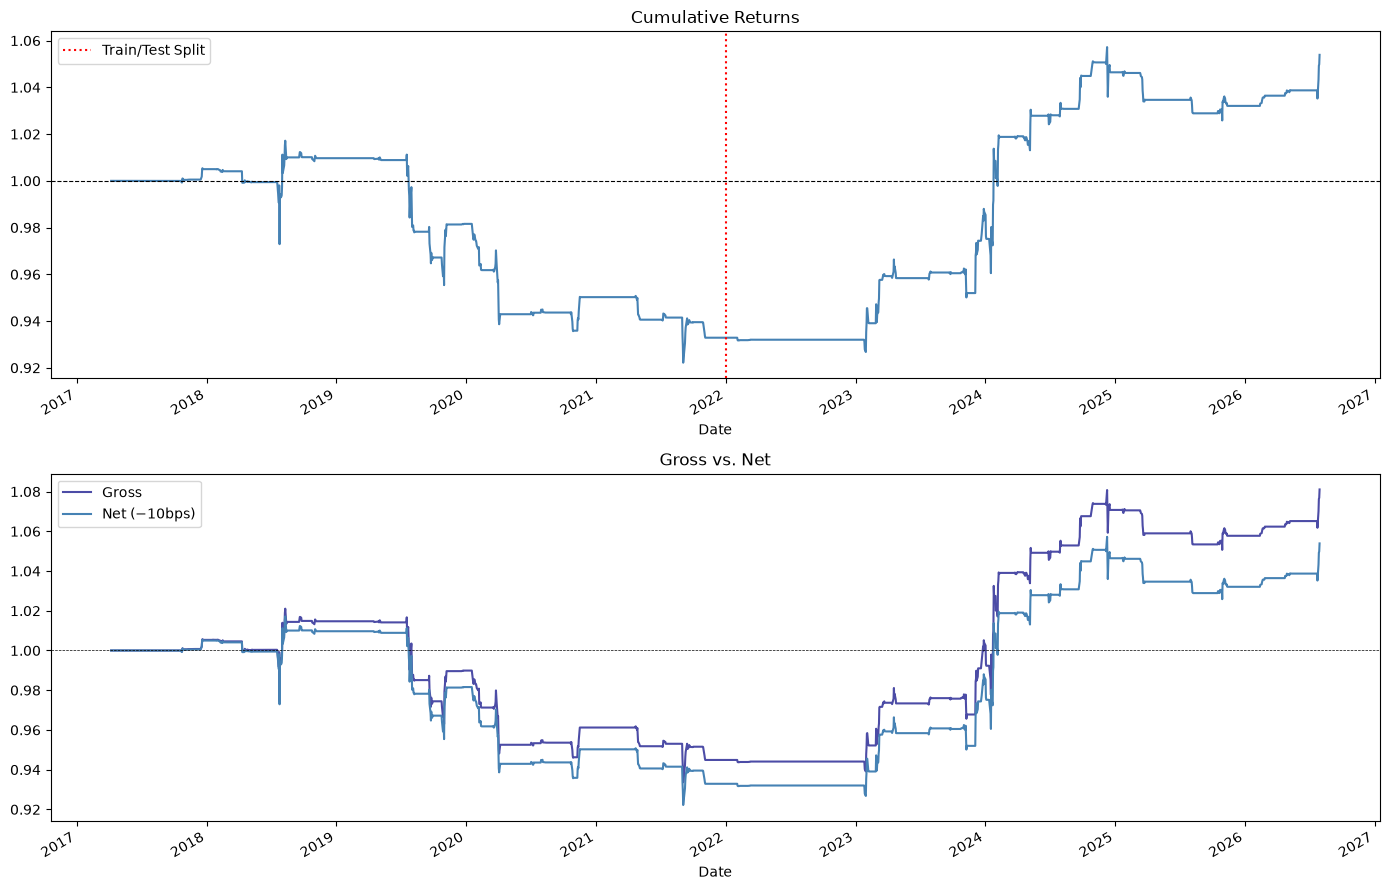

In [9]:
# Pre-COVID strategy gave Sharpe for some time, but the validation periods' higher zscores' range was conducive to trading opportunities! 
fig, axes = plt.subplots(2, 1, figsize = (14, 9))
(1 + net_returns).cumprod().plot(ax = axes[0], color = 'steelblue', linewidth = 1.5)
axes[0].axhline(1.0, color = 'black', linestyle = '--', linewidth = 0.8)

if 'dt' in globals() and hasattr(dt, 'test_start'):
    axes[0].axvline(pd.Timestamp(dt.test_start), color = 'red',
                    linestyle = ':', label = 'Train/Test Split')
title = "Cumulative Returns"
if 'perf' in globals():
    title += f" | Sharpe: {perf['sharpe_ratio']:.3f} | MDD: {perf['max_drawdown']:.1%}"
axes[0].set_title(title)
axes[0].legend()

(1 + trades['gross_return']).cumprod().plot(ax = axes[1], label = 'Gross', alpha = 0.7, color = 'navy')
(1 + trades['net_return']).cumprod().plot(ax = axes[1], label = 'Net (−10bps)', color = 'steelblue', linewidth = 1.5)
axes[1].axhline(1.0, color = 'black', linestyle = '--', linewidth = 0.5)
axes[1].legend()
axes[1].set_title("Gross vs. Net")

plt.tight_layout()
plt.show()

In [10]:
# This strategy generally performs well in a high Brent Crude environment, alongside the first quartile of the VIX
diag = bt.macro_regime_diagnostics(net_returns, macro_returns)
print("Sharpe by Macro Regime Quartile:")
print(diag.to_string())

Sharpe by Macro Regime Quartile:
          Q1     Q2     Q3     Q4
VIX    1.139 -1.444  0.155 -0.091
Brent -0.365 -0.908  0.558  1.152


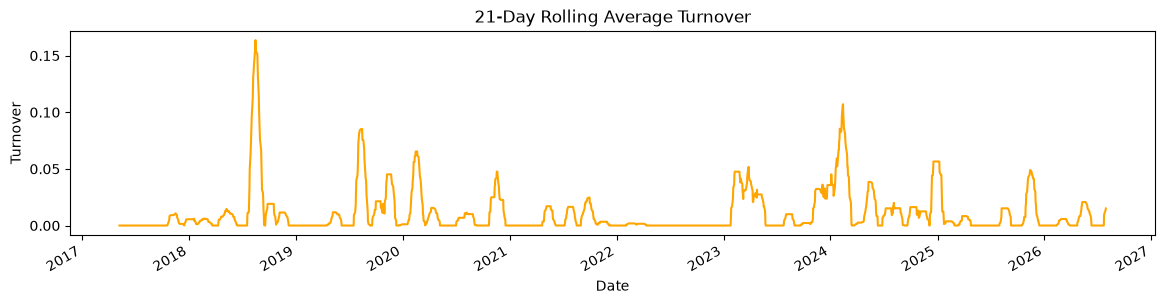

Avg daily turnover: 0.0109
Avg annual turnover: 2.75x


In [11]:
# Low overall turnover
trades['turnover'].rolling(21).mean().plot(figsize = (14, 3), color = 'orange', title = "21-Day Rolling Average Turnover")
plt.ylabel("Turnover")
plt.show()
print(f"Avg daily turnover: {trades['turnover'].mean():.4f}")
print(f"Avg annual turnover: {trades['turnover'].mean()*252:.2f}x")

In [12]:
# Saving some files for reference; although 04_Run.ipynb has the validation Sharpe
if 'perf' not in globals() or perf is None:
    perf = bt.compute_performance(net_returns, trades, macro_returns)
output_dir = Path("Outputs")
output_dir.mkdir(exist_ok = True)
net_returns.to_frame("net_return").to_csv(output_dir / "net_returns.csv")
perf.to_frame("strategy").to_csv(output_dir / "performance.csv")
positions.to_csv(output_dir / "signals.csv")
trades.to_csv(output_dir / "trades.csv")
print("Saved successfully.")

Saved successfully.


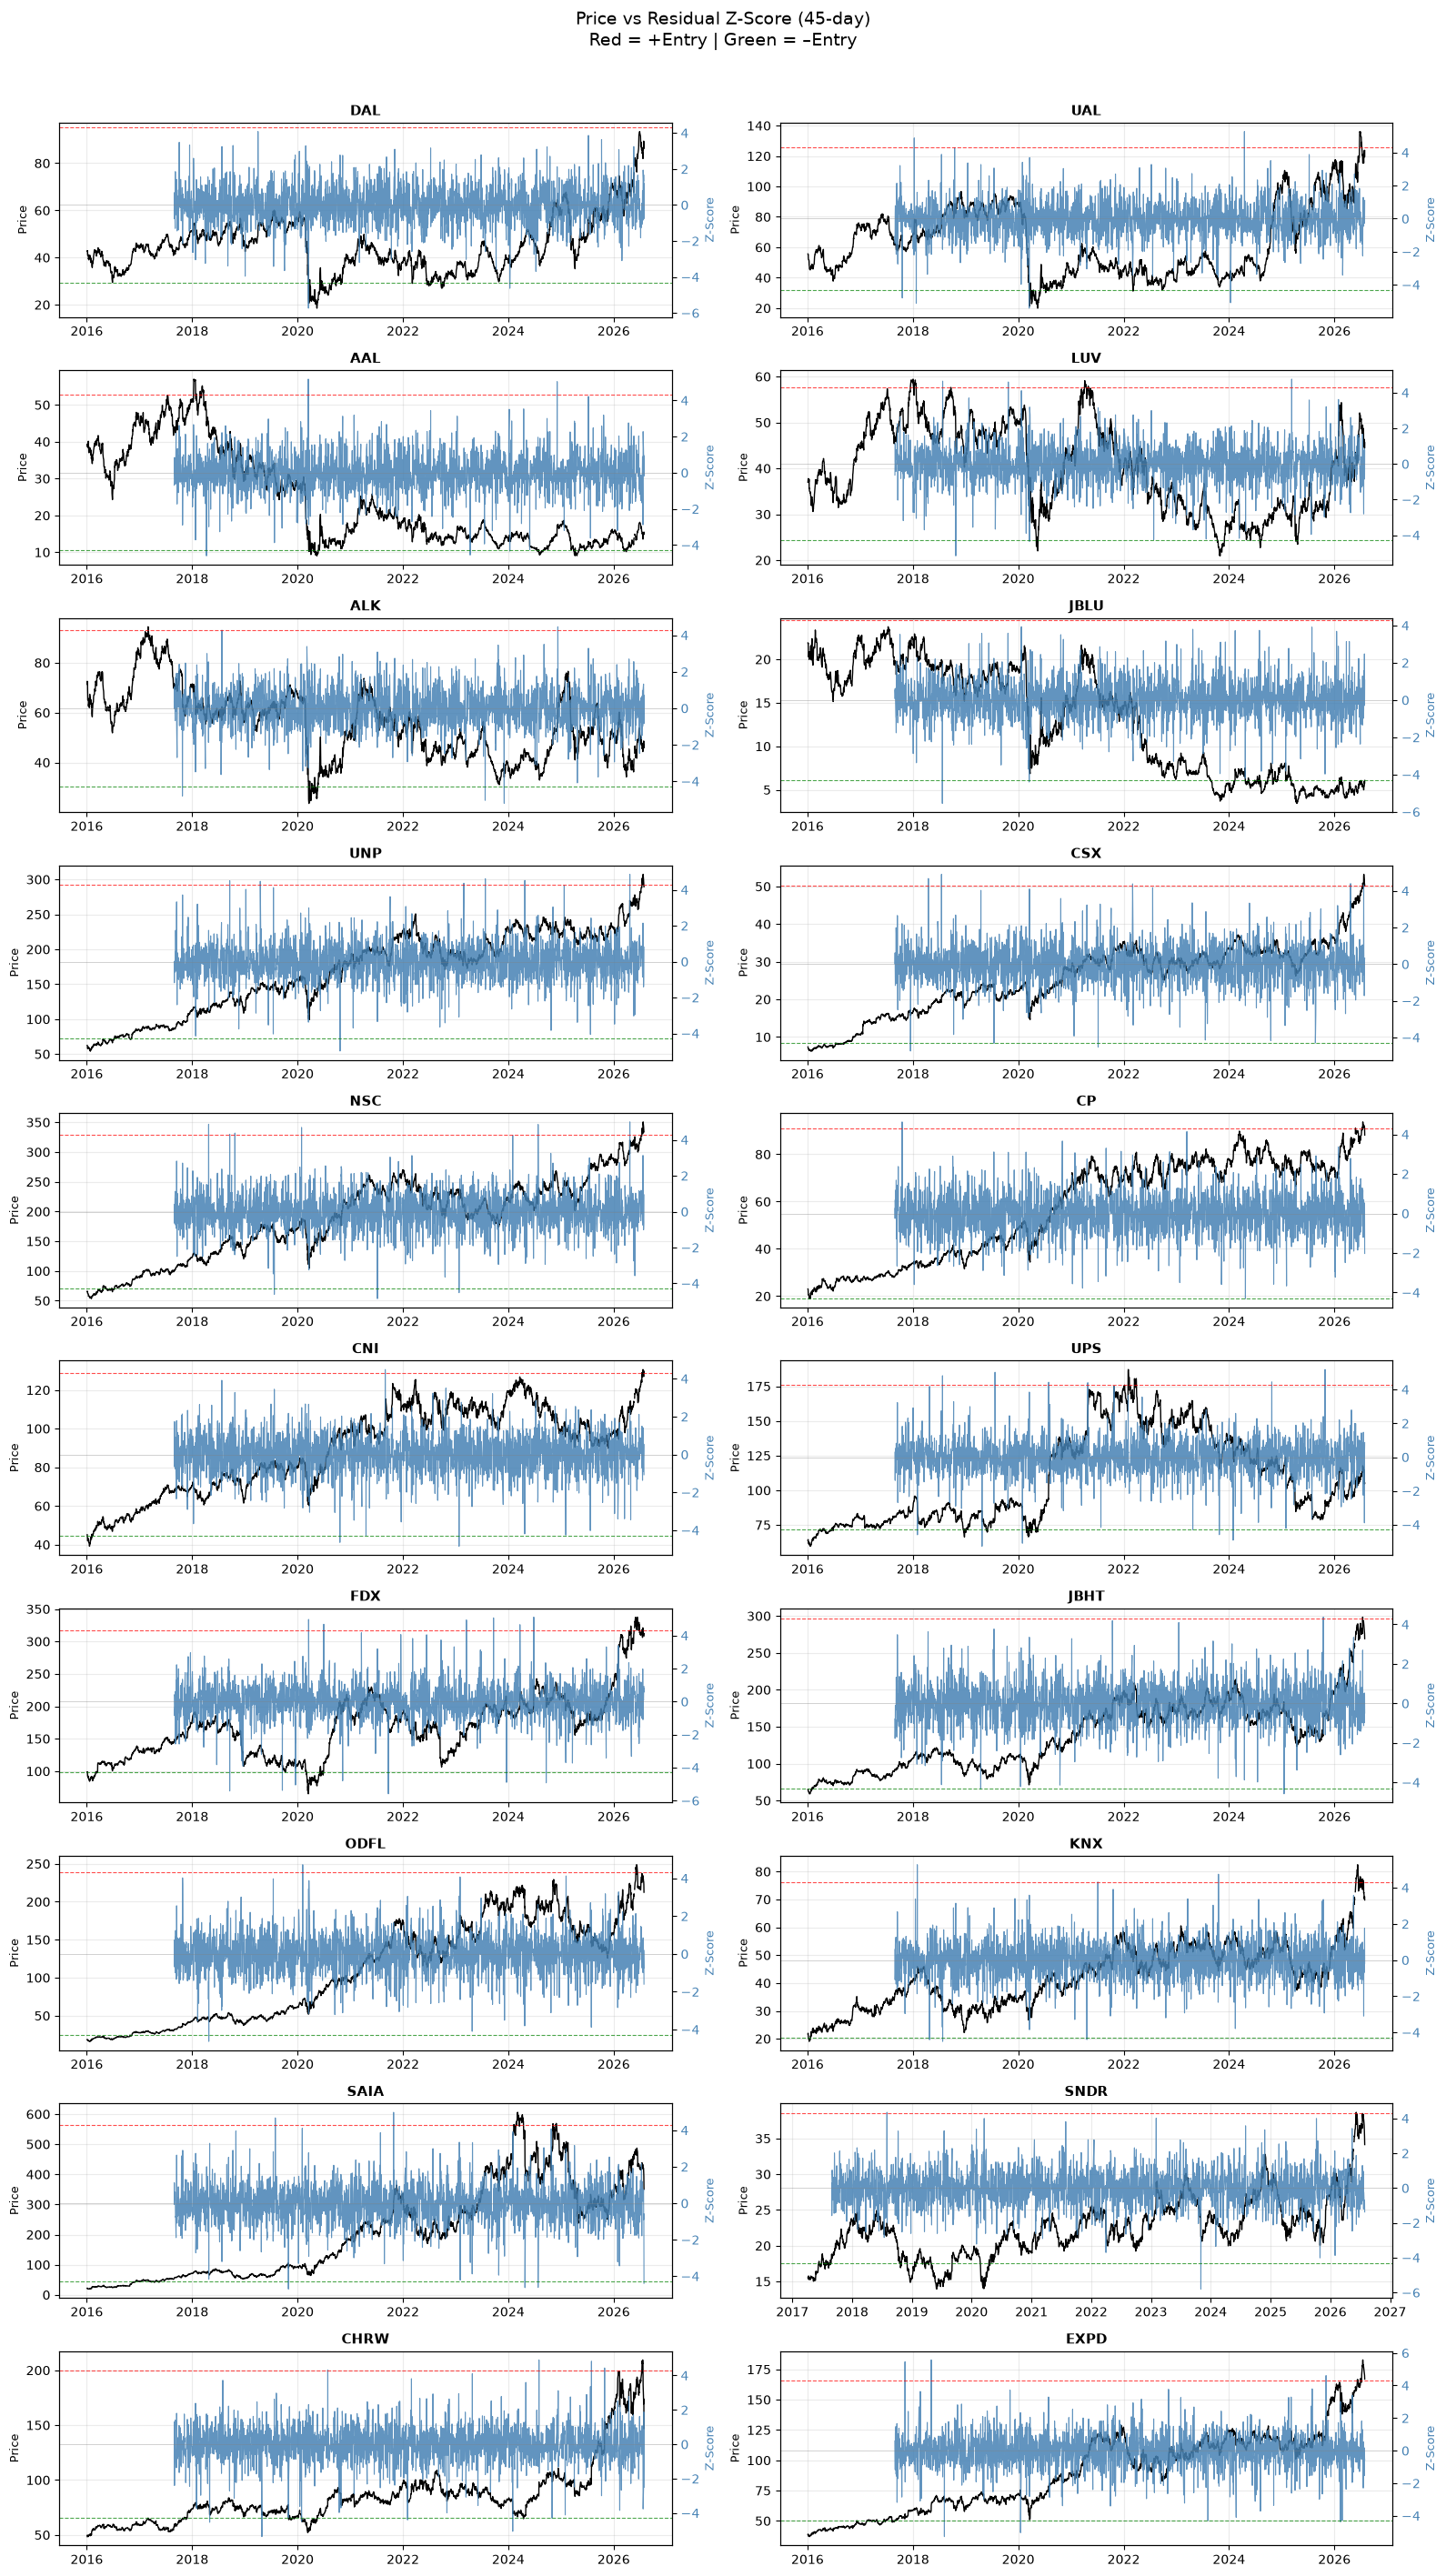

In [13]:
# Price vs Residual Z-Score for all stocks
z = md.compute_rolling_zscore(residuals, window = 45)
tickers = list(z.columns)
fig, axes = plt.subplots(nrows = 10, ncols = 2, figsize = (16, 28), sharex = False)
axes = axes.flatten()
for i, ticker in enumerate(tickers):
    ax = axes[i]
    ax.plot(prices[ticker].loc['2016':], color = 'black', linewidth = 1.0)
    ax.set_ylabel('Price', color = 'black', fontsize = 9)
    ax.tick_params(axis = 'y', labelcolor = 'black')
    ax2 = ax.twinx()
    ax2.plot(z[ticker].loc['2016':], color = 'steelblue', linewidth = 0.8, alpha = 0.85)
    ax2.axhline( bt.entry_threshold, color = 'red',   linestyle = '--', linewidth = 0.8, alpha = 0.7)
    ax2.axhline(-bt.entry_threshold, color = 'green', linestyle = '--', linewidth = 0.8, alpha = 0.7)
    ax2.axhline(0, color = 'gray', linestyle = '-', linewidth = 0.5, alpha = 0.5)
    ax2.set_ylabel('Z-Score', color = 'steelblue', fontsize = 9)
    ax2.tick_params(axis = 'y', labelcolor = 'steelblue')
    ax.set_title(ticker, fontsize = 11, fontweight = 'bold')
    ax.grid(True, alpha = 0.25)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Price vs Residual Z-Score (45-day)\nRed = +Entry | Green = –Entry", fontsize = 14, y = 1.01)
plt.tight_layout()
plt.show()

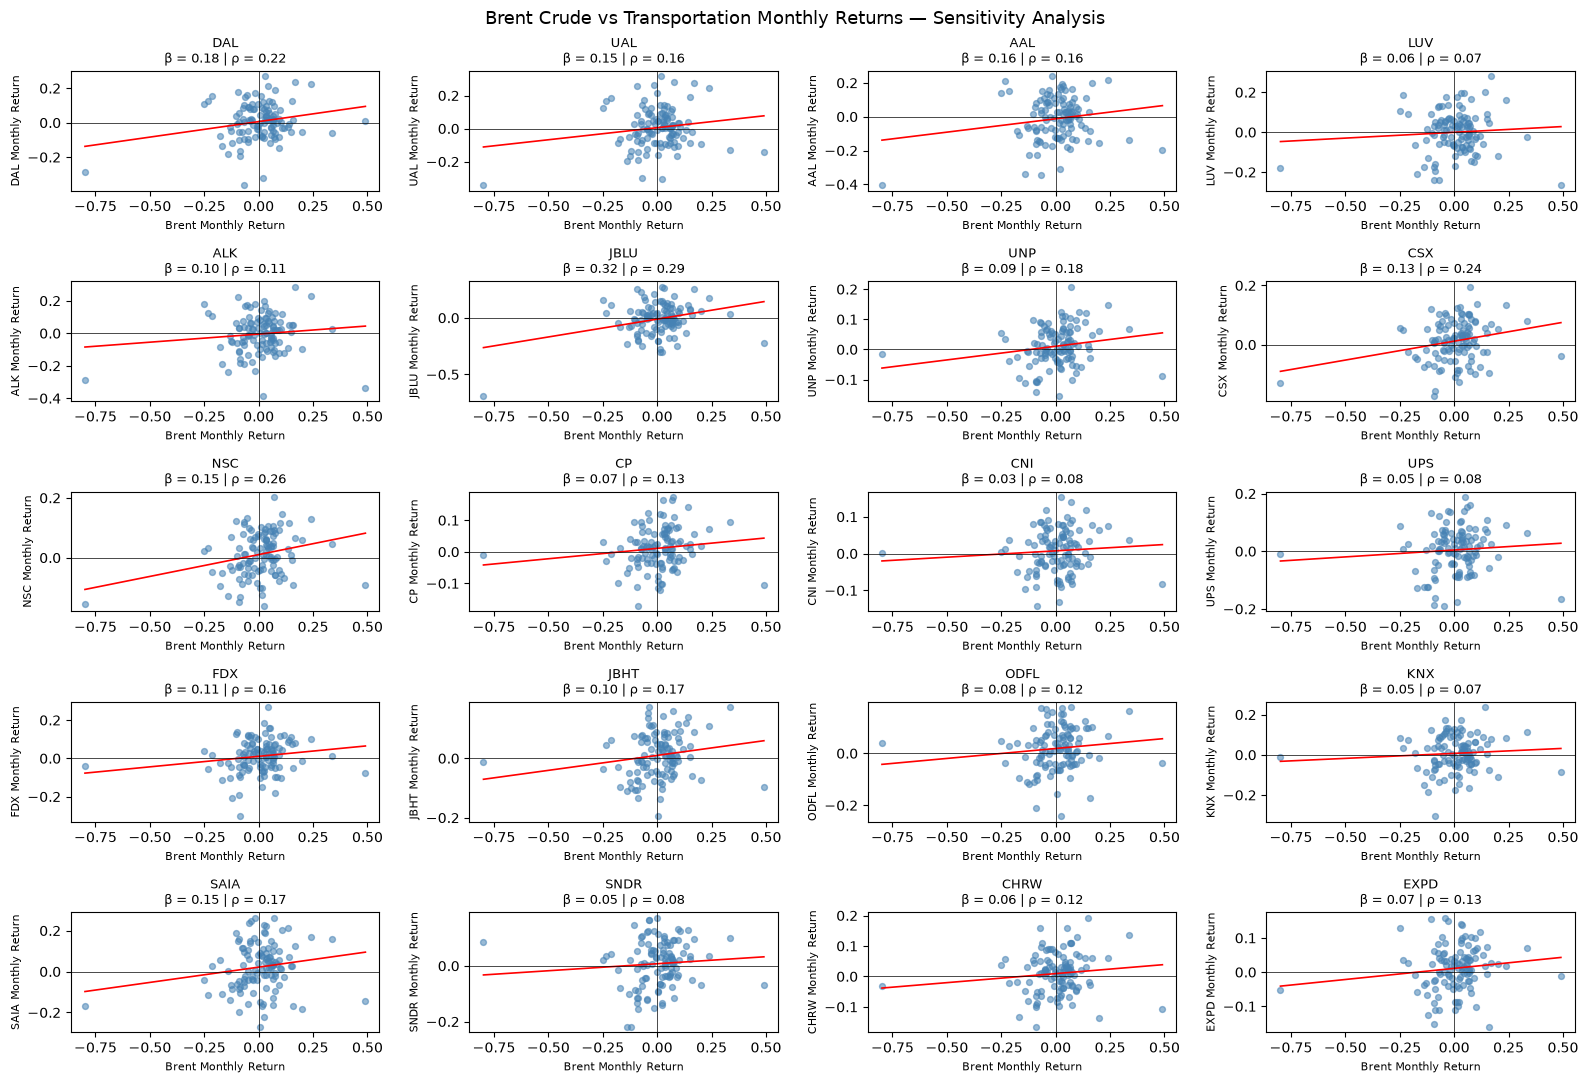

In [14]:
# Brent Crude vs Transportation — Monthly Sensitivity
fig, axes = plt.subplots(5, 4, figsize = (16, 11))
axes = axes.flatten()
brent_monthly = np.log(macro_returns['Brent']).diff().resample('ME').sum().dropna()
for i, t in enumerate(stocks_returns.columns):
    stock_monthly = stocks_returns[t].resample('ME').sum().dropna()
    common = brent_monthly.index.intersection(stock_monthly.index)
    x = brent_monthly.loc[common]
    y = stock_monthly.loc[common]
    axes[i].scatter(x, y, alpha = 0.55, s = 18, color = 'steelblue')
    if len(x) > 10:
        m, b = np.polyfit(x, y, 1)
        xl = np.linspace(x.min(), x.max(), 100)
        axes[i].plot(xl, m * xl + b, color = 'red', linewidth = 1.2)
        corr = x.corr(y)
        axes[i].set_title(f"{t}\nβ = {m:.2f} | ρ = {corr:.2f}", fontsize = 9)
    else:
        axes[i].set_title(t, fontsize = 9)
    axes[i].axhline(0, color = 'black', linewidth = 0.5)
    axes[i].axvline(0, color = 'black', linewidth = 0.5)
    axes[i].set_xlabel("Brent Monthly Return", fontsize = 8)
    axes[i].set_ylabel(f"{t} Monthly Return", fontsize = 8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Brent Crude vs Transportation Monthly Returns — Sensitivity Analysis", fontsize = 13)
plt.tight_layout()
plt.show()

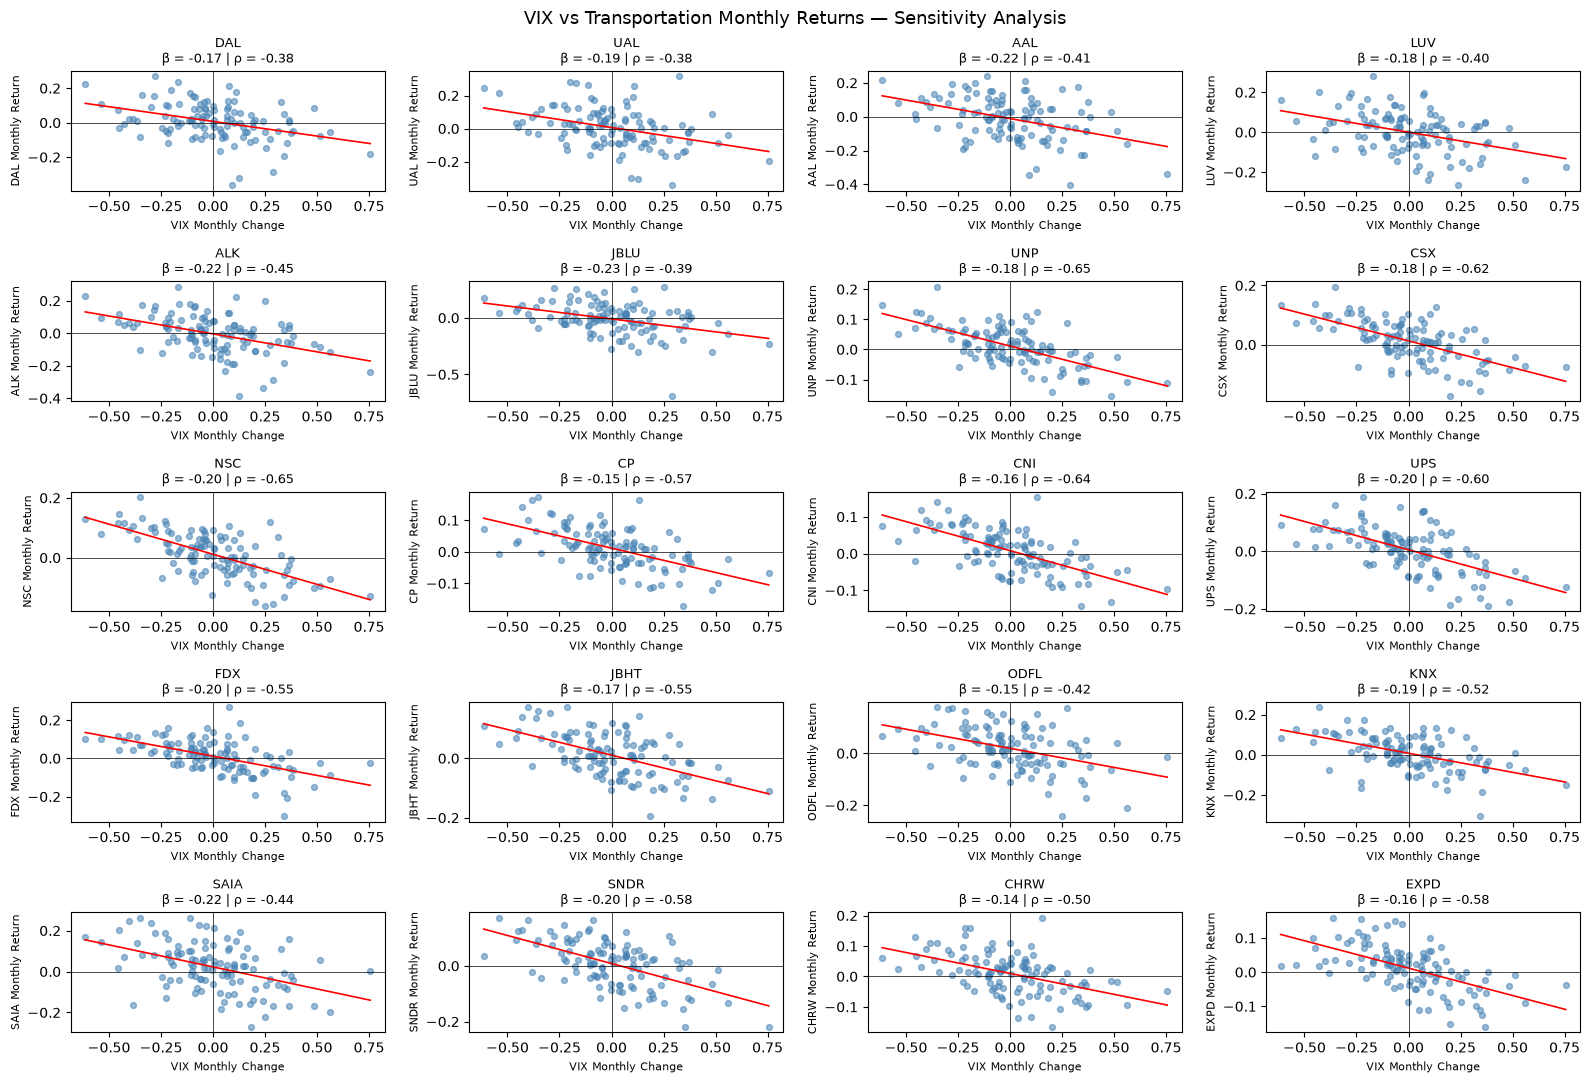

In [15]:
# VIX vs Transportation — Monthly Sensitivity
fig, axes = plt.subplots(5, 4, figsize = (16, 11))
axes = axes.flatten()
vix_monthly = np.log(macro_returns['VIX']).diff().resample('ME').sum().dropna()
for i, t in enumerate(stocks_returns.columns):
    stock_monthly = stocks_returns[t].resample('ME').sum().dropna()
    common = vix_monthly.index.intersection(stock_monthly.index)
    x = vix_monthly.loc[common]
    y = stock_monthly.loc[common]
    axes[i].scatter(x, y, alpha = 0.55, s = 18, color = 'steelblue')
    if len(x) > 10:
        m, b = np.polyfit(x, y, 1)
        xl = np.linspace(x.min(), x.max(), 100)
        axes[i].plot(xl, m * xl + b, color = 'red', linewidth = 1.2)
        corr = x.corr(y)
        axes[i].set_title(f"{t}\nβ = {m:.2f} | ρ = {corr:.2f}", fontsize = 9)
    else:
        axes[i].set_title(t, fontsize = 9)
    axes[i].axhline(0, color = 'black', linewidth = 0.5)
    axes[i].axvline(0, color = 'black', linewidth = 0.5)
    axes[i].set_xlabel("VIX Monthly Change", fontsize = 8)
    axes[i].set_ylabel(f"{t} Monthly Return", fontsize = 8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("VIX vs Transportation Monthly Returns — Sensitivity Analysis", fontsize = 13)
plt.tight_layout()
plt.show()

In [16]:
# Thanks for your time, allow me to take you to the final Exhibit (04_Run.ipynb)!